Phase 1: E-commerce Behavioral Telemetry Analysis.

In [1]:
# 1. Autoreload magic so changes in our .py files update instantly
%load_ext autoreload
%autoreload 2
    
import os
import sys
import urllib.request
import pandas as pd
from utils.marketing_eda import plot_correlation_matrix, plot_feature_densities
from utils.marketing_evaluation import evaluate_threshold

# 2. Define the local path and the public UCI repository URL
data_dir = '../data/raw'
file_path = f'{data_dir}/online_shoppers_intention.csv'
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00276/online_shoppers_intention.csv'

# Fetch the data automatically if it's missing
if not os.path.exists(file_path):
    print("Downloading dataset from UCI Machine Learning Repository...")
    os.makedirs(data_dir, exist_ok=True)
    urllib.request.urlretrieve(url, file_path)
    print("✅ Download complete!")
else:
    print("✅ Local dataset found.")

✅ Local dataset found.


In [2]:
# load the data
df = pd.read_csv(file_path)
df.head(3)

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.0,0.0,0.1,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False


In [3]:
# --- ENGINEER CUSTOMER JOURNEY KPIs ---
# We calculate average time spent per page type to gauge the depth of the user's session.
# Using .replace(0, 1) safely prevents ZeroDivisionError on users who didn't visit those pages.

df['Avg_Product_Time'] = df['ProductRelated_Duration'] / df['ProductRelated'].replace(0, 1)
df['Avg_Admin_Time'] = df['Administrative_Duration'] / df['Administrative'].replace(0, 1)
df['Avg_Info_Time'] = df['Informational_Duration'] / df['Informational'].replace(0, 1)

print("✅ Engineered Session Intent Metrics Successfully.")
display(df[['Avg_Product_Time', 'Avg_Admin_Time', 'Avg_Info_Time']].describe())

✅ Engineered Session Intent Metrics Successfully.


,Avg_Product_Time,Avg_Admin_Time,Avg_Info_Time
count,12330.000000,12330.000000,12330.000000
mean,37.633690,20.196282,14.807761
std,44.767916,45.995553,65.551312
min,0.000000,0.000000,0.000000
25%,17.613281,0.000000,0.000000
50%,28.878189,5.091667,0.000000
75%,45.084444,24.360119,0.000000
max,1411.000000,1566.600000,1778.000000


In [4]:
# --- MULTICOLLINEARITY TEST (VIF) ---
from statsmodels.stats.outliers_influence import variance_inflation_factor

def check_collinearity(dataframe, numerical_columns):
    """Calculates VIF to detect redundant continuous marketing metrics."""
    temp_df = dataframe[numerical_columns].dropna() 
    
    vif_data = pd.DataFrame()
    vif_data["Feature"] = temp_df.columns
    vif_data["VIF_Score"] = [
        variance_inflation_factor(temp_df.values, i) 
        for i in range(len(temp_df.columns))
    ]
    return vif_data.sort_values(by="VIF_Score", ascending=False)

# Define our continuous journey metrics
num_cols = [
    'Administrative_Duration', 'Informational_Duration', 'ProductRelated_Duration',
    'BounceRates', 'ExitRates', 'PageValues', 'Avg_Product_Time'
]

print("📊 Variance Inflation Factor (VIF) Analysis:")
display(check_collinearity(df, num_cols))

📊 Variance Inflation Factor (VIF) Analysis:


,Feature,VIF_Score
4,ExitRates,6.792491
3,BounceRates,6.125093
2,ProductRelated_Duration,1.712081
6,Avg_Product_Time,1.637733
0,Administrative_Duration,1.373280
1,Informational_Duration,1.226599
5,PageValues,1.073940


In [5]:
# --- STATISTICAL SIGNIFICANCE TESTING ---
from scipy.stats import chi2_contingency

def test_categorical_significance(dataframe, category_col, target_col='Revenue'):
    """Runs a Chi-Square test against the target conversion variable."""
    contingency_table = pd.crosstab(dataframe[category_col], dataframe[target_col])
    chi2, p_value, dof, expected = chi2_contingency(contingency_table)
    
    print(f"--- Chi-Square Test: {category_col} vs {target_col} ---")
    print(f"P-Value: {p_value:.5e}")
    if p_value < 0.05:
        print("Result: ✅ Statistically Significant (Highly predictive feature)\n")
    else:
        print("Result: ⚠️ Not Significant (Feature might be noise)\n")

# Test our primary top-of-funnel traffic identifiers
test_categorical_significance(df, 'Month')
test_categorical_significance(df, 'OperatingSystems')
test_categorical_significance(df, 'Browser')
test_categorical_significance(df, 'Region')
test_categorical_significance(df, 'VisitorType')
test_categorical_significance(df, 'Weekend')
test_categorical_significance(df, 'TrafficType')

--- Chi-Square Test: Month vs Revenue ---
P-Value: 2.23879e-77
Result: ✅ Statistically Significant (Highly predictive feature)

--- Chi-Square Test: OperatingSystems vs Revenue ---
P-Value: 1.41609e-13
Result: ✅ Statistically Significant (Highly predictive feature)

--- Chi-Square Test: Browser vs Revenue ---
P-Value: 6.08754e-03
Result: ✅ Statistically Significant (Highly predictive feature)

--- Chi-Square Test: Region vs Revenue ---
P-Value: 3.21425e-01
Result: ⚠️ Not Significant (Feature might be noise)

--- Chi-Square Test: VisitorType vs Revenue ---
P-Value: 4.26990e-30
Result: ✅ Statistically Significant (Highly predictive feature)

--- Chi-Square Test: Weekend vs Revenue ---
P-Value: 1.26633e-03
Result: ✅ Statistically Significant (Highly predictive feature)

--- Chi-Square Test: TrafficType vs Revenue ---
P-Value: 1.65274e-67
Result: ✅ Statistically Significant (Highly predictive feature)



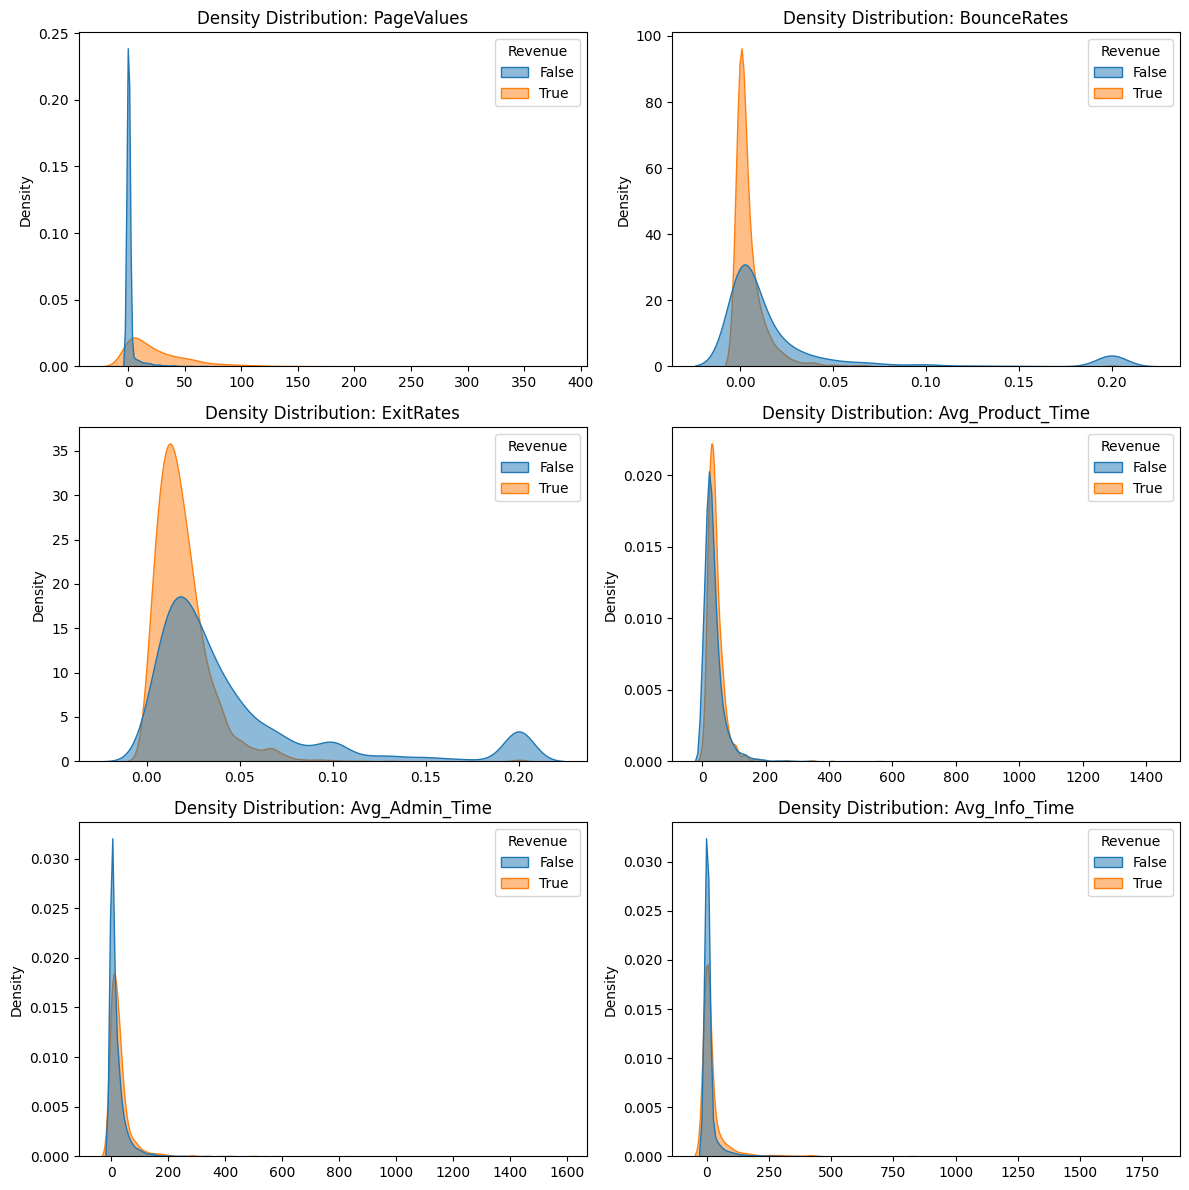

In [6]:
# Plot the density curves for our key metrics
key_metrics = ['PageValues', 'BounceRates', 'ExitRates', 'Avg_Product_Time', 'Avg_Admin_Time', 'Avg_Info_Time']
plot_feature_densities(df, features=key_metrics)